In [81]:
import pandas as pd
import numpy as np
import openpyxl as xl

In [82]:
# path = "../raw-data/SHPD consolidated.xlsx"
# det_df = pd.read_excel(path, sheet_name = "21-24 Det")

path = "../raw-data/shpd-plumb.csv"
det_df = pd.read_csv(path)

# print(det_df.describe())
# print(det_df["Opinion 6E"].unique())
# so there is no effect, effect with proposal, and effect with agreement

# adding in the labels that I did...
labels = pd.read_csv('../raw-data/labels.csv')
det_df = pd.merge(det_df, labels, how = "left", on = 'Project Name')
print(det_df.columns.to_list())

['Project Number', 'Project Name', 'Date Opinion 106', 'Opinion 106', 'Opinion 106 Comment', 'Date Opinion 6E', 'Opinion 6E', 'Opinion 6E Comment', 'Statutes', 'Agency', 'Island', 'Tax Map Keys', 'Label']


## Cleaning

We have to make some things right for the analysis.

1. need to create year variable using substring from permit id
2. need to standardize formats (use the clean part of the workbook?)

In [83]:
# smol, need to make NaN to strings in label column
det_df['Label'] = det_df['Label'].fillna("").astype(str) # converts NaNs to "" then safe .lower()

In [84]:
# cleaning up the dependent output variables

def classify_outcome(text: str) -> str:
    # if it does not exist
    if not isinstance(text, str):
        return None
    # forces to be lower case and without any spaces/newlines
    s = text.strip().lower()

    if "no" in s:
        return "no effect"
    elif "agreed" in s:
        return "effect with agreed commitments"
    elif "proposed" in s:
        return "effect with proposed commitments"
    else:
        return "NA"

def binary_outcome(text: str) -> str:
    if not isinstance(text, str):
        return None
    
    s = text.strip().lower() #lower just in case
    if "no" in s:
        return "no effect"
    if "effect" in s:
        return "effect"
    else:
        return "NA"


det_df["Opinion 6E"] = det_df["Opinion 6E"].apply(classify_outcome)
print(det_df["Opinion 6E"].unique())

det_df["opinion_6e_binary"] = det_df["Opinion 6E"].apply(binary_outcome)

<StringArray>
[                       'no effect',   'effect with agreed commitments',
 'effect with proposed commitments',                                nan]
Length: 4, dtype: str


In [85]:
# cleaning descriptions
from spellchecker import SpellChecker
import re

stopwords = {
    # Administrative / Process terms
    "permit", "permits", "permitting", "application", "applications", "project", "request", "existing", 
    "tmk", "job", "concurrence", "determination", "management", "department", 
    "state", "county", "coh", "smx", "cwrm", "gd", "id", "no", "name", 
    "statutes", "agency", "island", # "clearinghouse",
    
    # Common Connectors
    "for", "the", "and", "with", "from", "this", "that", "was", "were", "of"
    
    # # Numbers, Years, and Codes
    # "pw", "pweng", "eng",
    "2020", "2021", "2022", "2023", "a2021", "a2022", "a2023", "t2021", 
    "001", "phase", "1", "2", "3", "4", "5", "6", "7", "8", "9", "0", "por",
    
    # Location / Geographic Noise
    "maui", "honolulu", "hawaii", "oahu", "kauai", "lanai", "molokai",
    #"street", "st", "rd", "road", "highway",
    
    # Legal and Business Entities
    # "llc", "inc", "corp", "trust" #"owner", "family"
}

def clean(text, stopwords = stopwords):
    text = text.lower()
    text = re.sub(r'\d+', '', text) # digits
    text = re.sub(r'[^a-z\s]', '', text)
    # return text
    #remove matches to stopwords
    pattern = r'\b(' + '|'.join(re.escape(word) for word in stopwords) + r')\b\s*'
    text = re.sub(pattern, '', text)
    return text #.strip()

# import spacy
# nlp = spacy.load("en_core_web_sm")

# i feel like this is unnecessary now...
# def clean_permit_text(text):
#     doc = nlp(str(text).lower())
#     # Keep only words that are NOT stopwords and are alphabetic
#     tokens = [token.lemma_ for token in doc if token.text not in stopwords and token.is_alpha]
#     return " ".join(tokens)


det_df["Project Name"] = det_df["Project Name"].apply(clean)
print(det_df["Label"].dtype)
det_df["Label"] = det_df["Label"].apply(clean)
# det_df['Clean_Name'] = det_df['Project Name'].apply(clean_permit_text)

# no need to do this? since we fixed the spelling mistakes
# spell = SpellChecker()

# def spellCheck(text: str) -> str:
#     if pd.isna(text):
#         return text
#     return " ".join(spell.correction(w) or w for w in text.split())

# det_df["Project Name"] = det_df["Project Name"].apply(spellCheck)


str


In [86]:
for name in det_df["Label"]:
    if "permit" in name:
        print(name)
det_df.head()

,Project Number,Project Name,Date Opinion 106,Opinion 106,Opinion 106 Comment,Date Opinion 6E,Opinion 6E,Opinion 6E Comment,Statutes,Agency,Island,Tax Map Keys,Label,opinion_6e_binary
0,2012PR00405,dpp matthew alicia willis fax grading access...,NaN,NaN,NaN,5/12/2021,no effect,NaN,HRS 6E-42,NaN,Oʻahu,(1) 4-5-047:040,,no effect
1,2013PR04659,of sma use construction of a single family dwe...,NaN,NaN,NaN,6/16/2023,effect with agreed commitments,"SHPD hereby notifies the County of Hawaii, Dep...",HRS 6E-42,"County of Hawaii, Planning Department",Hawaiʻi,(3) 4-9-003:005,,effect
2,2014PR14733,dags nanakuli library,NaN,NaN,NaN,8/31/2023,no effect,NaN,HRS 6E-8,NaN,Oʻahu,189002065por.,,no effect
3,2015PR19955,clearinghouse cl princeville makai ranch road g h,NaN,NaN,NaN,8/31/2023,no effect,NaN,HRS 6E-42,NaN,Kauaʻi,453006026-040 (4) 5-3-006:042 (4) 5-3-006:044,,no effect
4,2015PR20185,kokua kalihi valley comprehensive family services,7/21/2022,No Historic Properties Affected,the SHPO opines a determination of no historic...,5/27/2022,no effect,“No historic properties affected” pursuant to ...,"HRS 6E-8,NHPA Section 106",NaN,Oʻahu,(1) 1-3-014:039,public facilities,no effect


# Unsupervised Learning - K Means Clustering & LDA

Typical, but it is a start. 


In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# tf-idf vectorizer
vectorizer = TfidfVectorizer(
    stop_words= list(stopwords),
    min_df = 5,
    ngram_range=(1,3))

X = vectorizer.fit_transform(det_df["Project Name"])

from sklearn.decomposition import TruncatedSVD
# use TruncatedSVD to do dimensionality reduction
svd = TruncatedSVD(n_components=50)
X_reduced = svd.fit_transform(X)

# then we run
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_reduced)

det_df["cluster"] = labels
# still in numbers so have to interpret them

In [88]:
terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(10):
    print("Cluster", i)
    print([terms[ind] for ind in centroids[i, :10]])

Cluster 0
['aa', 'ada', 'access road', 'accessory', 'additionalteration to', 'alarm', 'ala', 'act', 'additionalteration', 'afterthefact']
Cluster 1
['add', 'ada', 'access', 'add alt', 'ac', 'abandonment', 'accessory', 'act', 'addition alterations to', 'addition alteration to']
Cluster 2
['access', 'ac', 'abandonment', 'aa', 'academy', 'addition alteration', 'accessory', 'ala', 'air', 'addition alterations']
Cluster 3
['access', 'access road', 'addition', 'abandonment', 'ac', 'add alt', 'additionalteration', 'act', 'additions', 'addition alterations to']
Cluster 4
['abandonment', 'addition to', 'access road', 'accessory dwelling', 'adu', 'add', 'aa', 'alarm system', 'additionalteration to sfd', 'addition alterations to']
Cluster 5
['acres', 'ada', 'actions', 'access road', 'access', 'accessory dwelling', 'act', 'ac', 'add alt', 'abandonment']
Cluster 6
['academy', 'abandonment', 'addition alteration', 'addition', 'act', 'additionalteration to', 'agricultural', 'ais', 'add', 'adu']
Clust

In [89]:
# topic discovery with LDA

from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=10)
topics = lda.fit_transform(X)

det_df["topic"] = topics.argmax(axis=1)

terms = vectorizer.get_feature_names_out()

for i, comp in enumerate(lda.components_):
    words = np.array(terms)[np.argsort(comp)[-8:]]
    print(f"Topic {i}: {', '.join(words)}")

Topic 0: improvements, ex, beach, st, owners, housing, to, building
Topic 1: property pw eng, lot, pw eng, eng, pw, subdivision, property, grading
Topic 2: hotel, pv, water, waikiki, park, at, system, of
Topic 3: constructionpump installation, well constructionpump installation, constructionpump, well constructionpump, well construction, construction, installation, well
Topic 4: swimming pool, swimming, farm dwelling, of, farm, pool, new, dwelling
Topic 5: well, water service lateral, of, service lateral, water service, lateral, service, water
Topic 6: pl, building, demolition, church, pweng, center, improvements, of
Topic 7: house, addition, new, alteration, building, of, pweng, residence
Topic 8: notification tcns, development, trust, number, fcc, tower, llc, grubbing
Topic 9: doe, repairs, of, high, elementary school, elementary, building, school


In [90]:
# labelling for actual analysis
water_infra = ['well', 'pump', 'water', 'sewer']
pools = ['pools', 'pool']
housing = ['dwelling', 'residence', 'sfd', 'home', 'house', 'housing', 'apartment', 'courtyards', 'residential development', 'duplex', 'quadplex']
non_res = ['office', 'business', 'vacation', 'resort', 'tourism', 'church']
site_prep = ['grading', 'grubbing', 'stockpile', 'assessment']
alterations = ['add', 'addition', 'alt', 'alterations', 'alteration', 'convert', 'relocate', 'replacement']
telecom = ['fcc', 'antenna', 'cell tower', 'radio tower']
public_fac = ['college', 'doe', 'school', 'elementary', 'hs', 'library', 'university', 'uh', 'campus', 'doe', 'park', 'cemetary', 'memorial', 'classroom', 'public', 'corrections']
mitigation = ['monitoring', 'burial', 'mitigation', 'preservation', 'nature', 'natural', 'resevoir', 'AIS']
demolitions = ['demolitions', 'removal', 'demolition', 'removing']
public_works = ['street', 'highway', 'hw', 'roadway', 'tunnel', 'bridge', 'path', 'walkway']
fence_wall = ['fence', 'fencing', 'wall']
subdivisions = ['subdivision']

# it literally labels things top down, so make sure things are ordered - ABANDONED
def auto_label(text):
    text = str(text).lower()
    if any(w in text for w in housing):
        return 'Housing'
    if any(w in text for w in water_infra):
        return 'Water Infrastructure'
    if any(w in text for w in site_prep):
        return 'Site Prep'
    if any(w in text for w in telecom):
        return 'Telecom'
    if any(w in text for w in public_fac):
        return 'Public Facilities' 
    if any(w in text for w in mitigation):
        return 'Cultural Mitigation'
    if any(w in text for w in public_works):
        return 'Public Works'
    if any(w in text for w in pools):
        return 'Pools'
    if any(w in text for w in demolitions):
        return 'Demolitions'
    if any(w in text for w in fence_wall):
        return "Fencing/Wall"
    if any(w in text for w in non_res):
        return "Non-Residential"
    if any(w in text for w in subdivisions):
        return "Subdivisions"
    return 'Other'

# Apply to your dataframe
det_df['Category_Estimate'] = det_df['Project Name'].apply(auto_label)

## Category Maps
Here is the idea:
1. Residential
2. Water-related
3. Non-residential
4. Public facilities
5. Public works
6. Demolitions
7. Site Prep - includes mitigation, grading
8. Other

In [91]:
import re

# Organize your lists into a dictionary for easy iteration
CATEGORY_MAP = {
    'residential': ['dwelling', 'residence', 'residential', 'sfd', 'home', 'house', 'housing', 'apartment', 'courtyards', 'residential development', 'duplex', 'quadplex'],
    'water': ['well', 'pump', 'water', 'sewer', 'septic', 'catchment'],
    'site prep': ['grading', 'grubbing', 'stockpile', 'excavation', 'burial', 'mitigation', 'preservation', 'ais', 'archaeological', 'investigation'],
    'telecom': ['fcc', 'antenna', 'cell tower', 'radio tower', 'monopole', 'telecommunication'],
    'public facilities': ['college', 'middle school', 'high school', 'elementary', 'library', 'university', 'campus', 'park', 'cemetary', 'memorial', 'classroom', 'corrections', 'plant', 'station', 'education'],
    # 'mitigation': [],
    'public works': ['roadway', 'tunnel', 'bridge', 'path', 'walkway', 'sidewalk', 'paving', 'rehabilitation'],
    'demolition': ['demolitions', 'removal', 'demolition', 'removing'],
    # 'fencingwall': ['fence', 'fencing', 'wall', 'retaining wall'],
    'nonresidential': ['office', 'business', 'vacation', 'resort', 'tourism', 'church', 'commercial', 'retail', 'llc', 'trust', 'corporation', 'hotel', 'company'],
    # 'subdivisions': ['subdivision', 'consolidation']
}

def score_labeler(text):
    if not isinstance(text, str):
        return 'Other'
    
    text = text.lower()
    scores = {}

    for category, keywords in CATEGORY_MAP.items():
        score = 0
        for word in keywords:
            # Use regex for word boundaries to avoid partial matches (e.g., 'st' in 'stone')
            if re.escape(word) in text:
            #re.search(rf'\b{re.escape(word)}\b', text):
                score += 1
        scores[category] = score

    # Find the category with the maximum score
    max_score = max(scores.values())
    
    if max_score == 0:
        return 'other'
    
    # Get all categories that tied for the max score
    winners = [cat for cat, score in scores.items() if score == max_score]
    
    # Return the winner. If there's a tie, you could return "Multiple" 
    # or just the first one. Here we return the first one.
    return winners[0]

# Apply to your dataframe
det_df['Category_Scored'] = det_df['Project Name'].apply(score_labeler)

In [92]:
print(det_df['Category_Scored'].value_counts())

Category_Scored
other                1123
residential           514
water                 465
site prep             310
public facilities     271
nonresidential        157
public works           75
telecom                61
demolition             46
Name: count, dtype: int64


In [93]:
other_test = det_df[det_df['Category_Scored'] == "other"]
# print(other_test['Project Name'])

for name in other_test["Project Name"]:
    print(name)

kokua kalihi valley comprehensive family services
crs seawall emergency repair at pililaau army recreation center waianae kai waianae 
ahuwale ditch storm drainage improvements wailupe 
punahou academy learning commons  punahou street 
pulehu farms subdivision ii file kula io pulehu farm subdivision 
of b  b t g  g t g  g  g  b t evans holdings development 
kawainui marsh restoration of habitat at mokulana kailua koolaupoko 
remove old signage replace new merger hfs federal credit union  mamane street honokaa 
hilo counseling center  keawe health center improvements dags hilo 
lihue wwtp process improvements lihue 
 ohukai baseyard subdivision file owners christopher hayes amp candice hayes kihei 
waimanalo irrigation system maunawili valley miscellaneous improvements doa kailua koolaupoko 
on effect waikolu valley irrigatin system repairs waikolu valley hoolehua 
kiuc kokee diversion modification flow release monitoring plans kokee 
of subdivision file haleakala acres subdivision 
vet

# Supervised Learning: Linear SVM 

We have some categories that we can work with at the very least.

In [94]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

label_df = det_df.dropna(subset = ['Label'])
label_df = label_df[label_df['Label'] != '']

print(label_df['Label'].unique())


<StringArray>
['public facilities',         'site prep',        'demolition',
    'nonresidential',             'other',       'residential',
      'public works',             'water',           'telecom']
Length: 9, dtype: str


In [109]:
# model pipeline
base_model = LinearSVC(class_weight = 'balanced', C = .5, random_state=42)
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range = (1,3), 
        min_df=2,
        stop_words = list(stopwords))),
    ('clf', CalibratedClassifierCV(
        base_model))
])

# training model
model.fit(label_df['Project Name'], label_df['Label'])

def hybrid_predict(text):
    # obtaining model prediction and confidence
    prob = model.predict_proba([text])[0]
    max_prob = max(prob)
    ml_label = model.classes_[prob.argmax()]

    # evaluate criteria to trust ML or default to scoring metric.

    if ml_label == 'Other' or max_prob < .4:
        heuristic_result = score_labeler(text)
        return heuristic_result
    
    return ml_label

In [110]:
# getting the other half to predict and then assembling together
# label vs category scored, I'm targeting the "other" category
predict_df = det_df[det_df['Label'] == ""].copy()
print(predict_df.shape)
predict_df['Label'] = predict_df['Project Name'].apply(lambda x: hybrid_predict(str(x)))
print(predict_df['Label'].value_counts())

full_df = pd.concat([predict_df, label_df]).sort_index()


(2353, 18)
Label
other                496
public facilities    413
residential          371
water                299
site prep            260
nonresidential       256
public works         163
telecom               50
demolition            45
Name: count, dtype: int64


In [111]:
full_df['Label'].value_counts()

Label
other                582
public facilities    534
residential          475
water                388
nonresidential       366
site prep            328
public works         220
telecom               69
demolition            60
Name: count, dtype: int64

557
--- Classification Report ---
                   precision    recall  f1-score   support

       demolition       1.00      0.33      0.50         3
   nonresidential       0.64      0.43      0.51        21
public facilities       0.57      0.87      0.69        23
     public works       1.00      0.55      0.71        11
      residential       0.78      0.90      0.84        20
        site prep       0.60      0.69      0.64        13
          telecom       1.00      0.50      0.67         4
            water       1.00      0.94      0.97        17

         accuracy                           0.72       112
        macro avg       0.82      0.65      0.69       112
     weighted avg       0.76      0.72      0.72       112



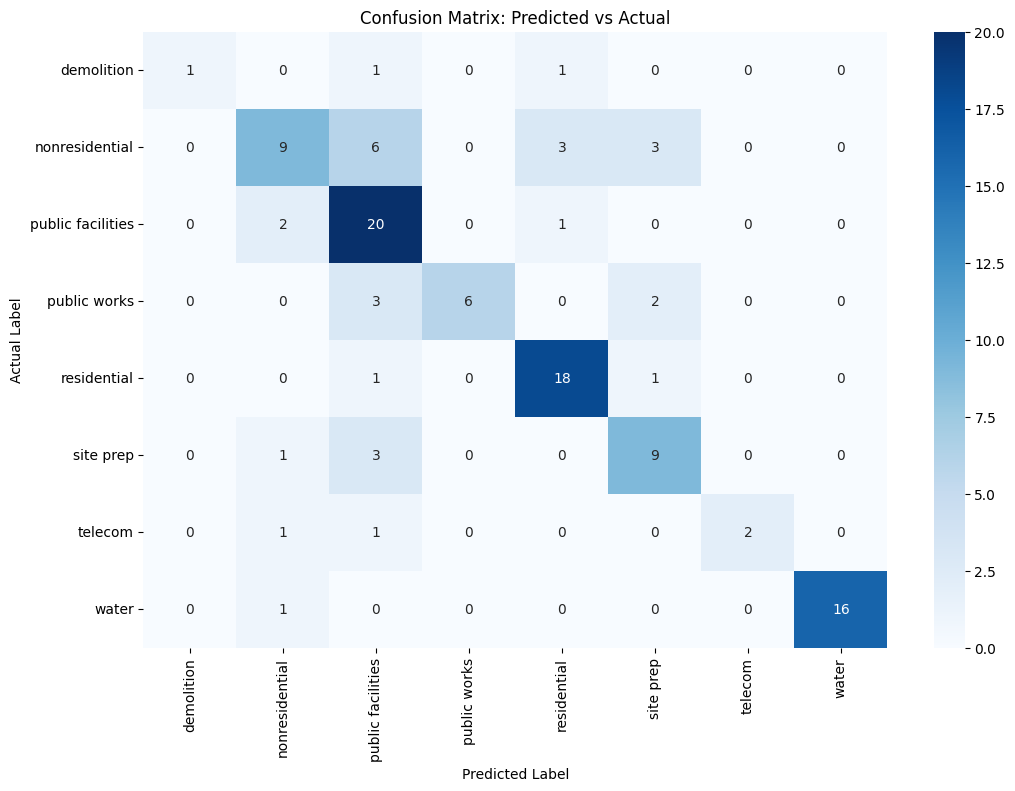

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_df = label_df[label_df['Label'] != 'other'].drop_duplicates()
print(test_df.shape[0])

# 1. Split your labeled data into training and evaluation sets
# 'stratify' ensures each category is represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    test_df['Project Name'], 
    test_df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=test_df['Label'] # Important for imbalanced data!
)

# 2. Re-train the model on just the training portion
model.fit(X_train, y_train)

# 3. Predict on the "unseen" test portion
y_pred = model.predict(X_test)

# 4. Print the performance metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize with a Confusion Matrix
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [115]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Define the cross-validation strategy
# We use 'Stratified' because your classes are imbalanced (e.g., Water vs Telecom)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Run cross-validation
# We use 'f1_weighted' since that is the metric you were tracking
cv_scores = cross_val_score(
    model, 
    label_df['Project Name'], 
    label_df['Label'], 
    cv=skf, 
    scoring='f1_weighted'
)

# 3. Output results
print(f"All CV Scores: {cv_scores}")
print(f"Mean F1-Score: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

All CV Scores: [0.71839755 0.73058421 0.68807604 0.6728672  0.6335568 ]
Mean F1-Score: 0.689
Standard Deviation: 0.034
